# Logistic Regression
- Liad Mandil, 315096073
- Maxim Prokopchuk, 337875397

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.model_selection import train_test_split , cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay, confusion_matrix
from sklearn import tree
from sklearn.model_selection import train_test_split , cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)
from sklearn.metrics import roc_curve, auc


-------------------------------

## Load Data

In [2]:
spaceship_data = pd.read_csv('final_data.csv')

## split to x and y

In [3]:
y = spaceship_data["Transported"].astype(int)
x = spaceship_data.drop(columns=["Transported"])

## Train-Test Split

In [4]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [5]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

## בדיקת ערכי ההייפר פרמטרים

In [6]:
results = []
best_score = 0
best_params_lr = None

In [7]:
C_list = [0.01, 0.1, 1, 10, 100]
penalties = ["l2", "l1"]   

for C in C_list:
    for pen in penalties:
        
        # solver must match penalty
        solver = "liblinear" if pen in ["l1", "l2"] else "lbfgs"

        lr_pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("lr", LogisticRegression(
                C=C,
                penalty=pen,
                solver=solver,
                max_iter=5000,
                random_state=42
            ))
        ])

        fold_scores = cross_val_score(
            lr_pipe,
            x_train, y_train,
            cv=cv,
            scoring="accuracy",
            n_jobs=-1
        )

        mean_score = fold_scores.mean()

        results.append({
            "penalty": pen,
            "C": C,
            "cv_mean": mean_score,
            "cv_std": fold_scores.std()
        })

        if mean_score > best_score:
            best_score = mean_score
            best_params_lr = {"penalty": pen, "C": C}

In [8]:
print("\nBest Logistic Regression params:", best_params_lr)
print(f"Best CV accuracy: {100 * best_score:.2f}%")

results_df = pd.DataFrame(results).sort_values("cv_mean", ascending=False)
display(results_df.head(10).round(4))


Best Logistic Regression params: {'penalty': 'l1', 'C': 10}
Best CV accuracy: 79.07%


,penalty,C,cv_mean,cv_std
9,l1,100.00,0.7907,0.0114
8,l2,100.00,0.7907,0.0114
7,l1,10.00,0.7907,0.0114
6,l2,10.00,0.7906,0.0112
4,l2,1.00,0.7904,0.0111
5,l1,1.00,0.7901,0.0111
3,l1,0.10,0.7893,0.0098
2,l2,0.10,0.7887,0.0118
0,l2,0.01,0.7787,0.0105
1,l1,0.01,0.7691,0.0118


#### best model

In [9]:
best_LR = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(
        C=best_params_lr["C"],
        penalty=best_params_lr["penalty"],
        solver="liblinear",
        max_iter=5000,
        random_state=42
    ))
])

best_LR.fit(x_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('lr',
                 LogisticRegression(C=10, max_iter=5000, penalty='l1',
                                    random_state=42, solver='liblinear'))])

## Results

In [10]:
y_pred_train = best_LR.predict(x_train)
accuracy_train = accuracy_score(y_train, y_pred_train)

print("="*40)
print("BEST Logistic Regression — TRAIN SET PERFORMANCE")
print("="*40)
print(f"Accuracy : {accuracy_train*100:.2f}%")
print("="*40)

BEST Logistic Regression — TRAIN SET PERFORMANCE
Accuracy : 79.29%


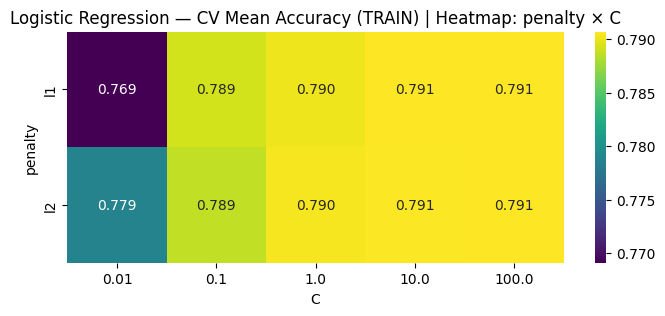

In [11]:
hm = results_df.pivot(index="penalty", columns="C", values="cv_mean")

plt.figure(figsize=(8,3))
sns.heatmap(hm, annot=True, fmt=".3f", cmap="viridis")
plt.title("Logistic Regression — CV Mean Accuracy (TRAIN) | Heatmap: penalty × C")
plt.xlabel("C")
plt.ylabel("penalty")
plt.show()

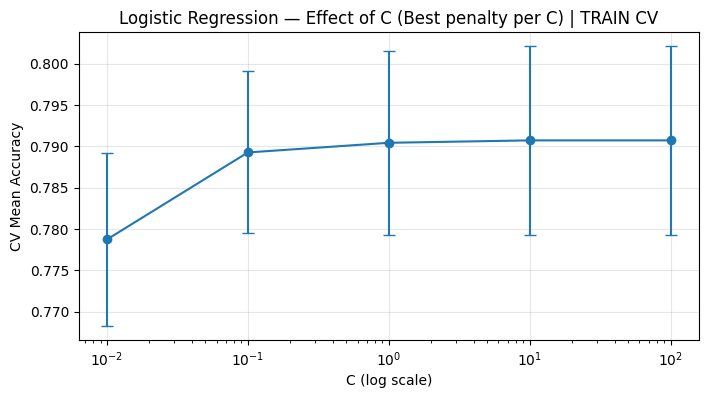

In [12]:
plot_c = (
    results_df
    .sort_values(["C", "cv_mean"], ascending=[True, False])
    .groupby("C", as_index=False)
    .head(1)
    .sort_values("C")
)

plt.figure(figsize=(8,4))
plt.errorbar(plot_c["C"], plot_c["cv_mean"], yerr=plot_c["cv_std"], fmt="o-", capsize=4)
plt.xscale("log")
plt.title("Logistic Regression — Effect of C (Best penalty per C) | TRAIN CV")
plt.xlabel("C (log scale)")
plt.ylabel("CV Mean Accuracy")
plt.grid(alpha=0.3)
plt.show()

<Figure size 500x500 with 0 Axes>

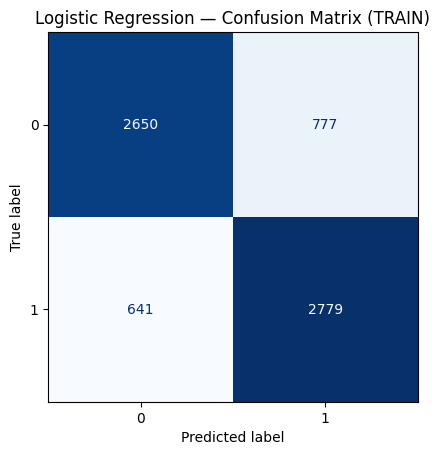

In [13]:
plt.figure(figsize=(5,5))
ConfusionMatrixDisplay.from_predictions(
    y_train,
    y_pred_train,
    cmap="Blues",
    colorbar=False
)
plt.title("Logistic Regression — Confusion Matrix (TRAIN)")
plt.show()

In [14]:
acc = accuracy_score(y_train, y_pred_train)
prec = precision_score(y_train, y_pred_train)
rec = recall_score(y_train, y_pred_train)
f1 = f1_score(y_train, y_pred_train)

metrics_df = pd.DataFrame([{
    "accuracy": acc,
    "precision": prec,
    "recall": rec,
    "f1_score": f1
}])

display(metrics_df.round(4))

print("\nClassification Report:")
print(classification_report(y_train, y_pred_train))

,accuracy,precision,recall,f1_score
0,0.7929,0.7815,0.8126,0.7967



Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.77      0.79      3427
           1       0.78      0.81      0.80      3420

    accuracy                           0.79      6847
   macro avg       0.79      0.79      0.79      6847
weighted avg       0.79      0.79      0.79      6847



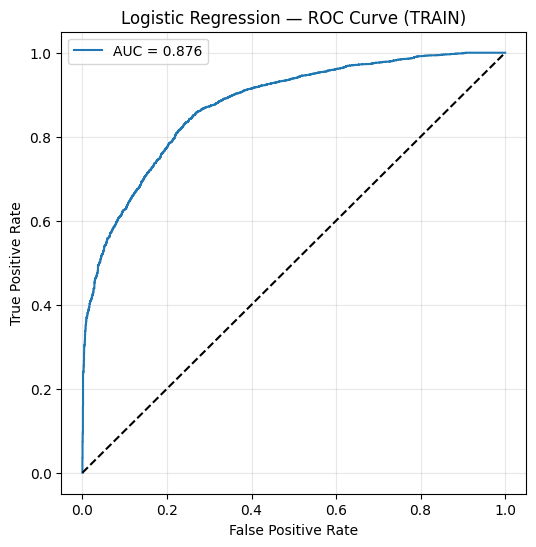

In [15]:
y_prob_train = best_LR.predict_proba(x_train)[:,1]

fpr, tpr, thresholds = roc_curve(y_train, y_prob_train)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Logistic Regression — ROC Curve (TRAIN)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()